In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
import geopandas as gpd


In [2]:
# Load data
climate_adm2 = pd.read_csv("../../data/raw/features/climate_features_lka_19.csv")
ml_targets = pd.read_csv("../../data/processed/sl_ml_targets_2025-11-13.csv")
hh_info = pd.read_csv("../../data/processed/hh_info.csv")
adm2_average = pd.read_csv("../../data/processed/adm2_average.csv")

# read in raw climate features
path_to_directory = 'C:/Users/gabriel.battcock/OneDrive - World Food Programme/General - MIMI Project/data_science/country_analysis/lka/'
climate_monthly = pd.read_csv(path_to_directory + 'raw_climate_feature_SL.csv')


## Year long average climate features

In [3]:

# Merge and summarize climate data
climate_adm2 = (
    climate_adm2
    .merge(ml_targets[['hhid', 'overall_mar']], left_on='household_id', right_on='hhid', how='left')
    .merge(hh_info[['hhid', 'adm2']].assign(hhid=lambda df: pd.to_numeric(df['hhid'], errors='coerce')),
           left_on='household_id', right_on='hhid', how='left')
    .groupby('adm2', as_index=False)
    .agg({
        'r3q': 'mean',
        'rfh_avg': 'mean',
        'vim_avg': 'mean',
        'overall_mar': 'mean'
    })
    .rename(columns={'overall_mar': 'mar'})
)

In [4]:

# Merge with nutrition indicators
adm2_inad = (
    adm2_average[['adm2', 'energy_kcal_q50'] + [col for col in adm2_average.columns if col.endswith('_inad')]]
    .merge(climate_adm2, on='adm2', how='left')
)

# Add province names
province_map = {
    1: "Western", 2: "Central", 3: "Southern", 4: "Northern", 5: "Eastern",
    6: "North Western", 7: "North Central", 8: "Uva", 9: "Sabaragamuwa"
}
adm2_inad['province'] = (adm2_inad['adm2'] // 10).round().map(province_map)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


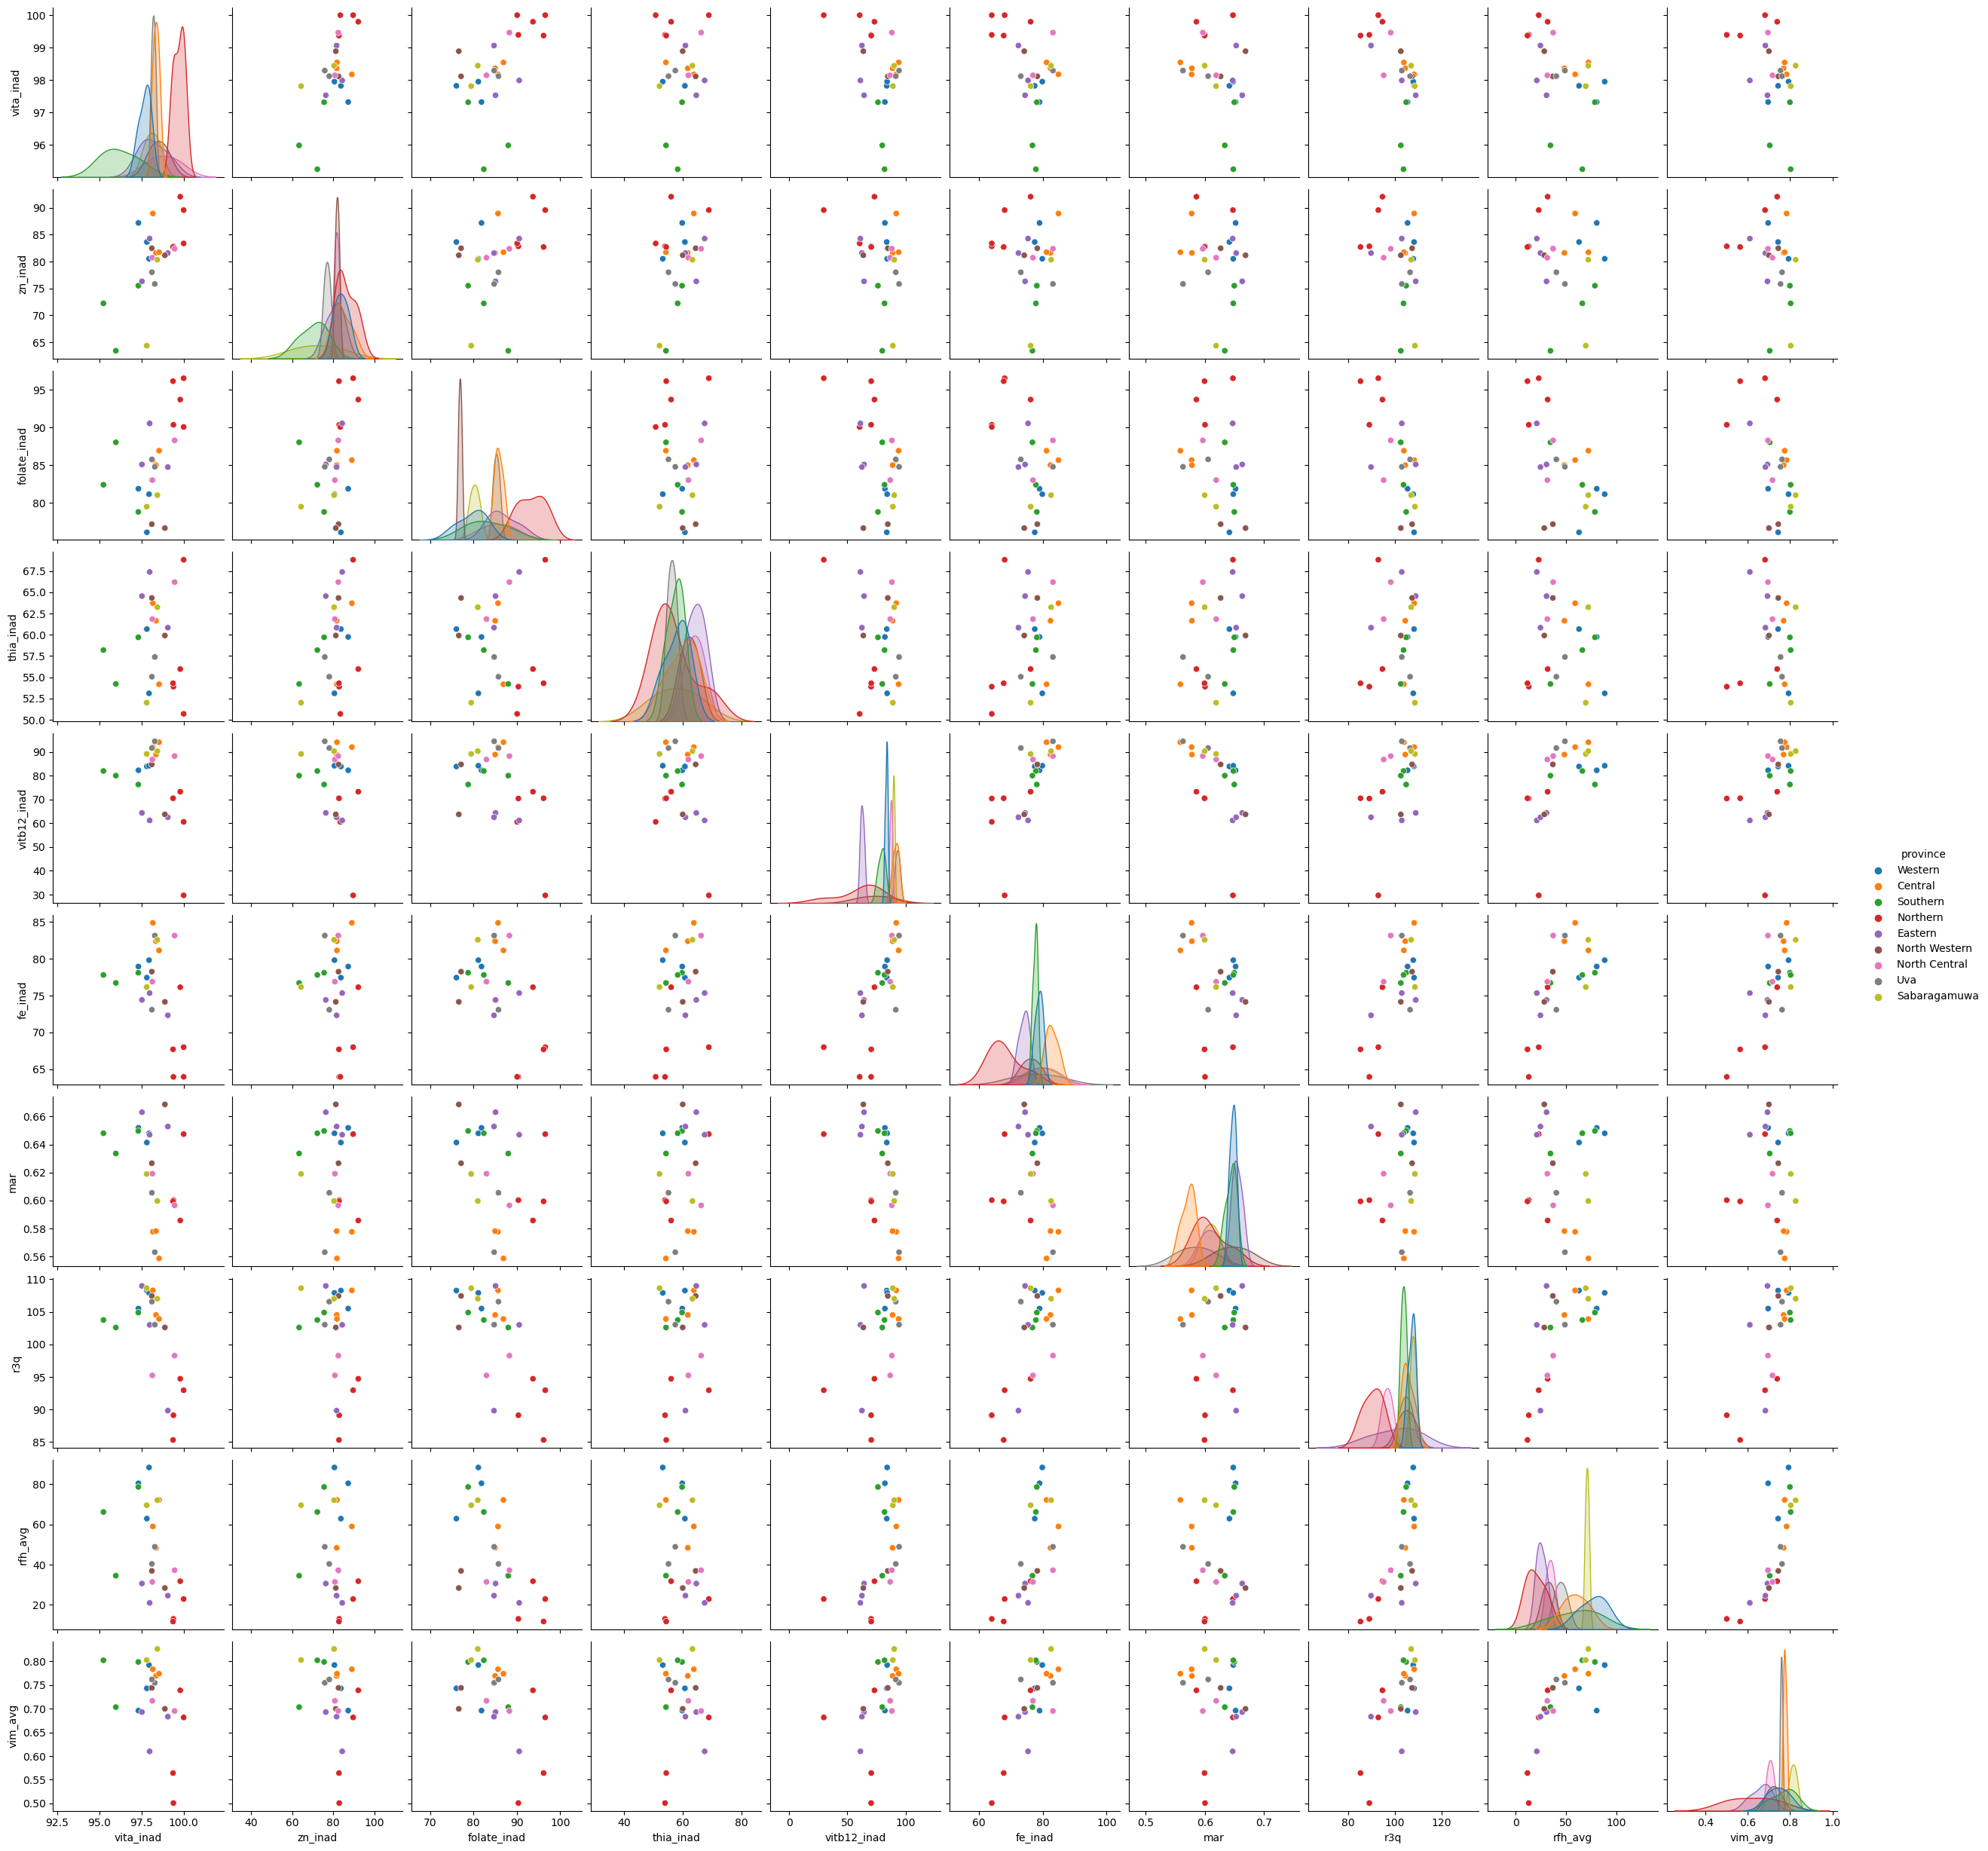

In [40]:

# Define variable groups
mn_col_names = list(adm2_inad.columns[2:8]) + [adm2_inad.columns[11]]
clim_col_names = list(adm2_inad.columns[8:11])

# Create output directory
os.makedirs("outputs/plots/climate", exist_ok=True)


sns.pairplot(adm2_inad, vars=mn_col_names + clim_col_names, hue="province")
# # Generate plots
# for i in mn_col_names:
#     for j in clim_col_names:
#         print(f"Plotting {i} vs {j}")
#         plt.figure(figsize=(8, 6))
#         sns.scatterplot(data=adm2_inad, x=j, y=i, hue='province', s=50)
#         sns.regplot(data=adm2_inad, x=j, y=i, scatter=False, color='black')

        
#         X = sm.add_constant(adm2_inad[j])
#         y = adm2_inad[i]

#         # Combine X and y into a single DataFrame for cleaning
#         data = pd.concat([X, y], axis=1)

#         # Remove rows with NaN or inf values
#         data_clean = data.replace([np.inf, -np.inf], np.nan).dropna()

#         # Separate cleaned X and y
#         X_clean = data_clean.iloc[:, :-1]
#         y_clean = data_clean.iloc[:, -1]

#         # Fit the model
#         model = sm.OLS(y_clean, X_clean).fit()

#         r_squared = model.rsquared
#         intercept, slope = model.params

#         pearson_r = model.params[1] / abs(model.params[1]) * r_squared**0.5

#         # Annotate with R² and equation
#         eq_label = f"$y = {intercept:.2f} + {slope:.2f}x$\n$R^2 = {r_squared:.2f}$\n$Pearson = {pearson_r:.2f}$"
#         plt.text(0.05, 0.95, eq_label, transform=plt.gca().transAxes,
#                  verticalalignment='top', horizontalalignment='left', fontsize=10)

#         plt.title(f"Scatterplot of {i} vs {j}")
#         plt.tight_layout()
#         plt.savefig(f"outputs/plots/climate/{i}_{j}.png")
#         plt.close()




## Monthly changes


In [6]:
climate_monthly['month'] = pd.to_datetime(climate_monthly['dates'], format="%Y-%m-%d").dt.strftime("%B")
climate_monthly['year'] = pd.to_datetime(climate_monthly['dates'], format="%Y-%m-%d").dt.strftime("%Y")

climate_monthly


,Unnamed: 0,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,vim,vim_avg,viq,dates,adm2Code,adm1Geometry,adm1Code,adm1Name,adm2Name,adm2Geometry,adm2Name_y,month,year
0,0,7.1167,65.4006,60.7000,242.5900,487.5833,913.6005,17.2110,26.5358,53.6232,0.8020,0.8029,99.8921,2017-01-01,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,January,2017
1,1,6.4167,59.6306,49.3500,208.9189,468.7500,860.7461,17.6645,25.4068,54.7216,0.7999,0.7988,100.1393,2017-01-11,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,January,2017
2,2,186.6500,55.0483,200.1833,180.0794,608.0000,787.8400,319.1595,110.8623,77.3170,0.7977,0.7938,100.4704,2017-01-21,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,January,2017
3,3,2.4333,45.1017,195.5000,159.7805,470.8000,717.3878,14.8365,121.6770,65.8649,0.7951,0.7882,100.8257,2017-02-01,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,February,2017
4,4,29.6167,33.3478,218.7000,133.4978,373.0500,642.5850,90.2703,161.5188,58.3784,0.7922,0.7827,101.1447,2017-02-11,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,February,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,2695,149.2500,130.8282,460.2308,424.5731,2278.7308,1146.0570,113.5626,108.3007,198.4029,0.8092,0.7984,101.2790,2019-11-11,25853,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,Kalutara,"POLYGON ((80.1494 6.8241, 80.1484 6.8239, 80.1...",Kalutara,November,2019
2696,2696,155.0962,139.0070,402.7885,405.2455,2127.3460,1209.5430,111.1724,99.4011,175.5678,0.8094,0.7985,101.2740,2019-11-21,25853,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,Kalutara,"POLYGON ((80.1494 6.8241, 80.1484 6.8239, 80.1...",Kalutara,November,2019
2697,2697,81.4615,85.1885,385.8077,355.0237,2083.5768,1185.0295,95.8676,108.5506,175.5063,0.8092,0.7982,101.2962,2019-12-01,25853,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,Kalutara,"POLYGON ((80.1494 6.8241, 80.1484 6.8239, 80.1...",Kalutara,December,2019
2698,2698,62.1923,75.8167,298.7500,300.0122,1682.2884,1144.7224,83.1416,99.5862,146.7562,0.8083,0.7969,101.3466,2019-12-11,25853,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,Kalutara,"POLYGON ((80.1494 6.8241, 80.1484 6.8239, 80.1...",Kalutara,December,2019


Just same month of survey (filter 2019)

In [28]:

# Filter for 2019 and aggregate monthly averages
agg_df = (
    climate_monthly[climate_monthly['year'] == '2019']
    .groupby(['month', 'year', 'adm2Code'])
    .agg({
        'r3q': 'mean',
        'rfh_avg': 'mean',
        'vim_avg': 'mean'
    })
    .reset_index()
)


# Convert month names to numbers
agg_df['month_num'] = pd.to_datetime(agg_df['month'], format='%B').dt.month

# Sort by adm2Code and numeric month
agg_df = agg_df.sort_values(['adm2Code', 'month_num'])




# Compute rolling 3-month average per adm2Code
rolling_df = (
    agg_df.groupby('adm2Code')[['r3q', 'rfh_avg', 'vim_avg']]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index()
)

# Add month/year back correctly
rolling_df['month'] = agg_df['month'].values
rolling_df['year'] = agg_df['year'].values

rolling_df


,adm2Code,level_1,r3q,rfh_avg,vim_avg,month,year
0,25830,100,62.520367,61.029500,0.814700,January,2019
1,25830,75,59.504450,47.373700,0.807317,February,2019
2,25830,175,56.733956,43.914533,0.796744,March,2019
3,25830,0,57.855900,42.789222,0.781267,April,2019
4,25830,200,57.466167,49.445889,0.771200,May,2019
...,...,...,...,...,...,...,...
295,41749,49,103.370767,62.838367,0.766233,August,2019
296,41749,299,124.983033,64.049222,0.763133,September,2019
297,41749,274,142.516200,79.898600,0.767544,October,2019
298,41749,249,141.449767,97.136922,0.778456,November,2019


In [29]:
ml_targets = ml_targets.merge(hh_info)
ml_targets['adm2'] = ml_targets['adm2'].astype(int)
    # Ensure ml_targets key column is also int
ml_targets = ml_targets.merge(hh_info)
ml_targets['adm2'] = ml_targets['adm2'].astype(int)

ml_targets['month'] = pd.to_datetime(ml_targets['month'], format="%m").dt.strftime("%B")
ml_targets['year'] = pd.to_datetime(ml_targets['year'], format="%Y").dt.strftime("%Y")

ml_aggregate = ml_targets.groupby(['month', 'year', 'adm2']).agg({
        'vita_rae_mcg':'median',
         'folate_mcg':'median',
         	'vitb12_mcg':'median',	'fe_mg':'median',	'zn_mg':'median',
            'overall_mar':'median'
    }) .reset_index()

ml_aggregate

ValueError: You are trying to merge on object and int64 columns. If you wish to proceed you should use pd.concat

In [30]:
def match_to_targets(df, ml_targets):
    # Mapping dictionary
    district_mapping = {
        11: 25851, 12: 25852, 13: 25853,
        21: 41748, 22: 25830, 23: 41749,
        31: 25846, 32: 25848, 33: 25847,
        41: 25839, 42: 25841, 43: 25843,
        44: 25842, 45: 25840, 51: 25833,
        52: 25832, 53: 25834, 61: 25837,
        62: 25838, 71: 25835, 72: 25836,
        81: 25849, 82: 25850, 91: 25845,
        92: 25844
    }

    # Reverse mapping
    district_mapping_reversed = {v: k for k, v in district_mapping.items()}

    # Ensure adm2Code is int for mapping
    df['adm2Code'] = df['adm2Code'].astype(int)

    # Map to original codes
    df['adm2'] = df['adm2Code'].map(district_mapping_reversed)


    

    df = df.merge(ml_targets, how='left')

    # Add province names
    province_map = {
        1: "Western", 2: "Central", 3: "Southern", 4: "Northern", 5: "Eastern",
        6: "North Western", 7: "North Central", 8: "Uva", 9: "Sabaragamuwa"
    }
    df['province'] = (df['adm2'] // 10).round().map(province_map)
    

    return df

# Usage
agg_df_hh = match_to_targets(agg_df, ml_targets)
rolling_df_hh = match_to_targets(rolling_df, ml_targets)
agg_df_adm2 = match_to_targets(agg_df, ml_aggregate)
rolling_df_adm2 = match_to_targets(rolling_df, ml_aggregate)

In [31]:
rolling_df_adm2

,adm2Code,level_1,r3q,rfh_avg,vim_avg,month,year,adm2,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar,province
0,25830,100,62.520367,61.029500,0.814700,January,2019,22,124.314697,175.652520,0.882627,9.536379,8.335539,0.594391,Central
1,25830,75,59.504450,47.373700,0.807317,February,2019,22,117.524557,149.523025,0.888863,8.797705,6.766590,0.546433,Central
2,25830,175,56.733956,43.914533,0.796744,March,2019,22,129.769724,127.323621,0.561035,7.452213,6.095416,0.452886,Central
3,25830,0,57.855900,42.789222,0.781267,April,2019,22,124.099500,180.879192,1.003363,9.477601,7.872068,0.621266,Central
4,25830,200,57.466167,49.445889,0.771200,May,2019,22,146.972048,169.777548,0.808900,9.393876,8.198214,0.569886,Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,41749,49,103.370767,62.838367,0.766233,August,2019,23,141.142409,166.250236,0.713142,9.717363,7.470195,0.570172,Central
296,41749,299,124.983033,64.049222,0.763133,September,2019,23,121.697277,156.152047,0.853656,9.220816,7.613189,0.564689,Central
297,41749,274,142.516200,79.898600,0.767544,October,2019,23,97.625669,152.817586,0.893165,9.264153,6.972661,0.562130,Central
298,41749,249,141.449767,97.136922,0.778456,November,2019,23,99.593314,148.717324,0.635665,8.254243,6.989379,0.502801,Central


In [37]:

# Define variable groups
mn_col_names = list(rolling_df_hh.columns[11:17])
clim_col_names = list(adm2_inad.columns[8:11])

months = rolling_df['month'].unique()

print(mn_col_names)
print(clim_col_names)
print(months)





['vita_rae_mcg', 'folate_mcg', 'vitb12_mcg', 'fe_mg', 'zn_mg', 'overall_mar']
['r3q', 'rfh_avg', 'vim_avg']
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August' 'September' 'October' 'November' 'December']


In [ ]:

from itertools import product



# Root output directory
root_dir = "../../outputs/plots/climate/monthly"
os.makedirs(root_dir, exist_ok=True)

def plot_relationship(df, month,  dir_name, root_dir=root_dir):
    """
    Creates a pairplot for the given dataframe and saves it in a specified subfolder.

    Parameters:
    - df: DataFrame containing the data
    - month: str or int, name of the month for the plot title and filename
    - mn_col_names: list of column names for micronutrient variables
    - clim_col_names: list of column names for climate variables
    - dir_name: str, name of the subfolder to create inside root_dir
    - root_dir: str, root directory where all subfolders will be created
    """

    # Create subfolder inside root_dir
    month_dir = os.path.join(root_dir, dir_name)
    os.makedirs(month_dir, exist_ok=True)

    # Generate the pairplot
    sns.pairplot(df, vars=mn_col_names + clim_col_names, hue="province")

    # Add title
    plt.suptitle(f"{month} Scatterplot", y=1.02)  # suptitle for pairplot
    plt.tight_layout()

    # Save plot in the specified folder
    output_path = os.path.join(month_dir, f"{month}.png")
    plt.savefig(output_path)
    plt.close()

    print(f"Plot saved to: {output_path}")




In [ ]:

for month in product(months):
    plot_relationship(agg_df_hh,month=month, dir_name ='hh_1month')

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-19>:40: UserWarning: The figure layout has changed to tight
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-19>:40: UserWarning: The figure layout has changed to tight
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-19>:40: UserWarning: The figure layout has changed to tight
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-19>:40: UserWarning: The figure layout has changed to tight
C:\Progr

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [38]:
for month in product(months):
    plot_relationship(rolling_df_adm2,month=month, dir_name ='adm2_3month')

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-38>:43: UserWarning: The figure layout has changed to tight


Plot saved to: ../../outputs/plots/climate/monthly\adm2_3month\('January',).png


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-38>:43: UserWarning: The figure layout has changed to tight


Plot saved to: ../../outputs/plots/climate/monthly\adm2_3month\('February',).png


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-38>:43: UserWarning: The figure layout has changed to tight


...

Plot saved to: ../../outputs/plots/climate/monthly\adm2_3month\('October',).png


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-38>:43: UserWarning: The figure layout has changed to tight


Plot saved to: ../../outputs/plots/climate/monthly\adm2_3month\('November',).png


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-38>:43: UserWarning: The figure layout has changed to tight


Plot saved to: ../../outputs/plots/climate/monthly\adm2_3month\('December',).png


In [39]:
for month in product(months):
    plot_relationship(rolling_df_hh,month=month, dir_name ='hh_3month')

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-39>:43: UserWarning: The figure layout has changed to tight


Plot saved to: ../../outputs/plots/climate/monthly\hh_3month\('January',).png


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-39>:43: UserWarning: The figure layout has changed to tight


Plot saved to: ../../outputs/plots/climate/monthly\hh_3month\('February',).png


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-39>:43: UserWarning: The figure layout has changed to tight


...

Plot saved to: ../../outputs/plots/climate/monthly\hh_3month\('October',).png


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-39>:43: UserWarning: The figure layout has changed to tight


Plot saved to: ../../outputs/plots/climate/monthly\hh_3month\('November',).png


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
<positron-console-cell-39>:43: UserWarning: The figure layout has changed to tight


Plot saved to: ../../outputs/plots/climate/monthly\hh_3month\('December',).png


In [41]:
for month in product(months):
    plot_relationship(agg_df_adm2,month=month, dir_name ='adm2_1month')

KeyError: 'vita_inad'